# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

Looking in indexes: https://download.pytorch.org/whl/cpuNote: you may need to restart the kernel to use updated packages.

Iteration 0, Loss: 0.9881577491760254
Iteration 100, Loss: 0.9200988411903381
Iteration 200, Loss: 0.8342400789260864
Iteration 300, Loss: 0.6844226717948914
Iteration 400, Loss: 0.5457267165184021
Iteration 500, Loss: 0.4454173445701599
Iteration 600, Loss: 0.36771923303604126
Iteration 700, Loss: 0.2989768087863922
Iteration 800, Loss: 0.2473190575838089
Iteration 900, Loss: 0.2128373384475708
Iteration 1000, Loss: 0.1907721906900406
Iteration 1100, Loss: 0.1780848652124405
Iteration 1200, Loss: 0.16950784623622894
Iteration 1300, Loss: 0.16302837431430817
Iteration 1400, Loss: 0.15707507729530334
Iteration 1500, Loss: 0.1506125032901764
Iteration 1600, Loss: 0.14469364285469055
Iteration 1700, Loss: 0.13946688175201416
Iteration 1800, Loss: 0.13492566347122192
Iteration 1900, Loss: 0.13066740334033966
Iteration 2000, Loss: 0.12584419548511505
Iteration 2100, Los

C:\Users\terra\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


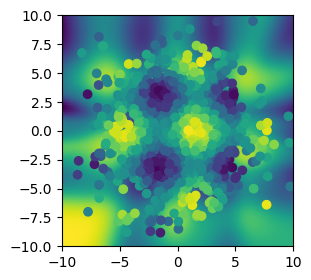

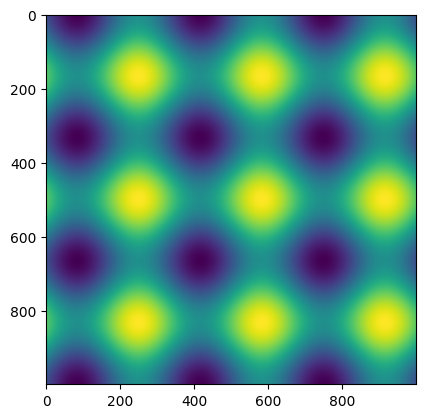

In [2]:
# Install PyTorch
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


import data
# lets look at the data
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
import torch

model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for t in range(10000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [ ]:
# AI is the broader umbrella term, which encompasses maschine learning. 
# Deep learning is under the umbrella of maschine learning.
# AI aims to create an intelligent system while maschine learing is the use of 
# pattern recognition in data to make predictions. Deep learning
# is a specialized branch of maschine learning that uses neural networks to
# handle complexer tasks and data.

What is a neural network?

In [ ]:
# A neural network imitates the human brain, using interconnected layered nodes for inputs and otputs
# for processing. It is the foundation for deep learning.

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [ ]:
# @ is the size of the input layer, 50 is the size of the output layer

What does the activation function do?

In [ ]:
# It introduces non-linearity into the network, enabling it to learn 
# and model complex relationships in data.

What is a loss function? Why do we need one?

In [ ]:
# It measures how well a neural network's predictions match the actual target 
# values and it calculates the difference between the predicted output 
# and the true output.
# The loss function is needed because it provides a way 
# to quantify the error.

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [ ]:
# We call it before loss.backward() in order to clear any previously 
# accumulated gradients in the model's parameters.
# Clearing them means that each training step starts with fresh, 
# correct gradient values.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

Iteration 0, Loss: 0.9845117330551147
Iteration 100, Loss: 0.3765849471092224
Iteration 200, Loss: 0.19655053317546844
Iteration 300, Loss: 0.13711869716644287
Iteration 400, Loss: 0.11567961424589157
Iteration 500, Loss: 0.10838726162910461
Iteration 600, Loss: 0.10466127097606659
Iteration 700, Loss: 0.09943936765193939
Iteration 800, Loss: 0.08507741242647171
Iteration 900, Loss: 0.07314375042915344


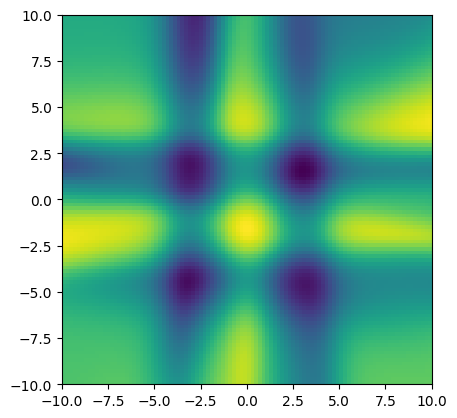

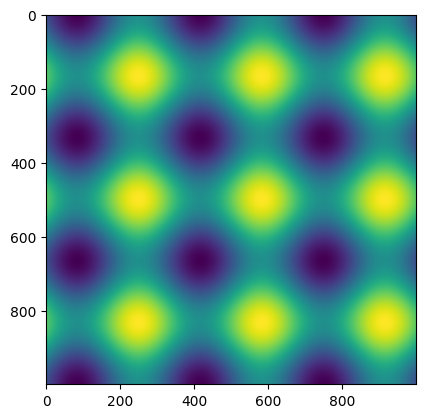

In [3]:
#old
#model = torch.nn.Sequential(
#    torch.nn.Linear(2, 50),
 #   torch.nn.Sigmoid(),
  #  torch.nn.Linear(50, 1)
#)

#new
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [ ]:
# Within the 1000 iteration, the loss functions for 50 neurons was bigger.
# for 30 it ranged from 0.07 to 0.3, but for 50 it was up to 0.9

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

Iteration 0, Loss: 1.1726511716842651
Iteration 100, Loss: 0.29341983795166016
Iteration 200, Loss: 0.16454783082008362
Iteration 300, Loss: 0.12036663293838501
Iteration 400, Loss: 0.10569824278354645
Iteration 500, Loss: 0.09702639281749725
Iteration 600, Loss: 0.08903016149997711
Iteration 700, Loss: 0.08362492173910141
Iteration 800, Loss: 0.0728665217757225
Iteration 900, Loss: 0.059556104242801666


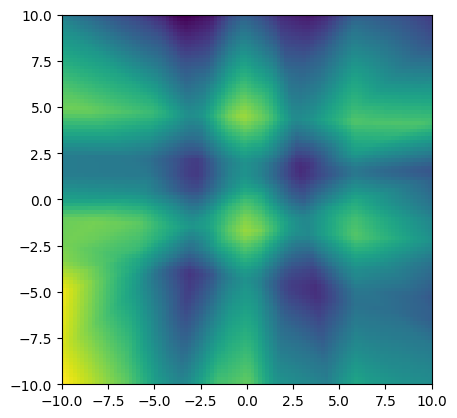

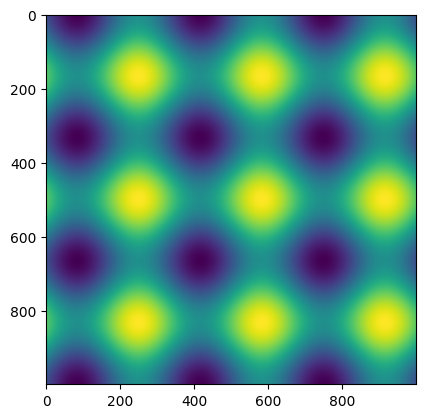

In [5]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()



#The range of the error increases, now we have a max error of 1.4, before it was 0.4

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

Iteration 0, Loss: 1.1862136125564575
Iteration 100, Loss: 0.21106795966625214
Iteration 200, Loss: 0.13398736715316772
Iteration 300, Loss: 0.07214372605085373
Iteration 400, Loss: 0.04274120554327965
Iteration 500, Loss: 0.03498150035738945
Iteration 600, Loss: 0.028465375304222107
Iteration 700, Loss: 0.02408861741423607
Iteration 800, Loss: 0.021361110731959343
Iteration 900, Loss: 0.01901860348880291


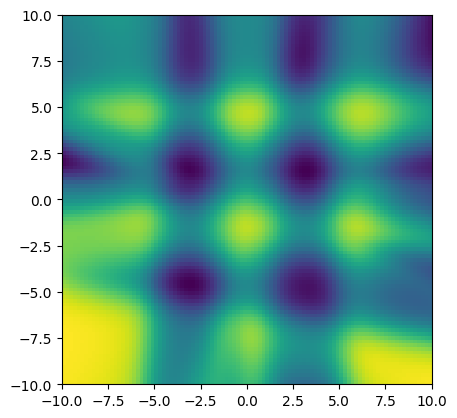

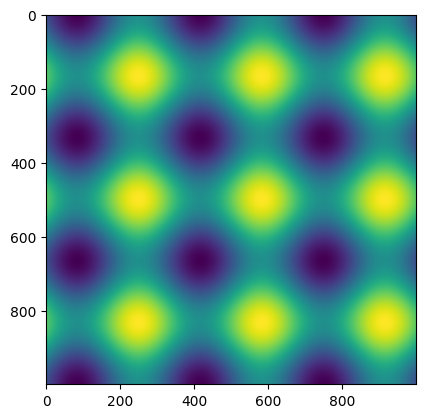

In [6]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Tanh(),
    torch.nn.Linear(50, 1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()


#just as with nn.ReLu, the range of the loss function increases, as well as spreads apart more.

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [10]:
# nn.Sigmoid() maps inputs between 0 and 1, often 
# used in binary classification tasks. nn.ReLU() outputs 0 for negative
# inputs and the input value itself for positive values, increasing 
# efficiency. nn.Tanh() maps input between -1 and 1 and is commonly used 
# in tasks requiring symmetric outputs.

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

Iteration 0, Loss: 1.1472294330596924
Iteration 100, Loss: 0.9407603740692139
Iteration 200, Loss: 0.9020079374313354
Iteration 300, Loss: 0.8320438861846924
Iteration 400, Loss: 0.7307221293449402
Iteration 500, Loss: 0.6207021474838257
Iteration 600, Loss: 0.5241127610206604
Iteration 700, Loss: 0.4521980881690979
Iteration 800, Loss: 0.4004027247428894
Iteration 900, Loss: 0.356699138879776


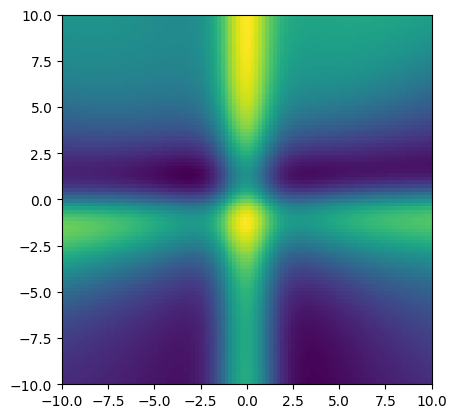

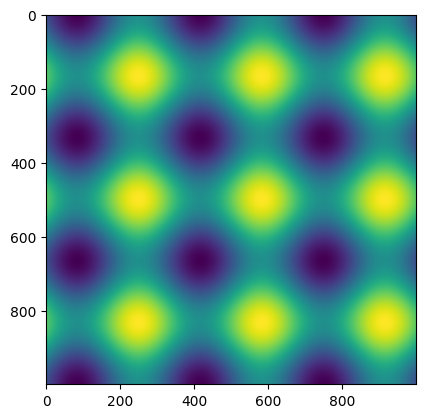

In [9]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()


# The max here is 1.29, while the max in lecture was 0.4

Modify your model to have **two hidden layers** instead of one. Give that code here.

Iteration 0, Loss: 0.9695661664009094
Iteration 100, Loss: 0.3027334213256836
Iteration 200, Loss: 0.16364139318466187
Iteration 300, Loss: 0.1424541175365448
Iteration 400, Loss: 0.1304427981376648
Iteration 500, Loss: 0.12078298628330231
Iteration 600, Loss: 0.10968665033578873
Iteration 700, Loss: 0.10187596827745438
Iteration 800, Loss: 0.09652438759803772
Iteration 900, Loss: 0.10002307593822479


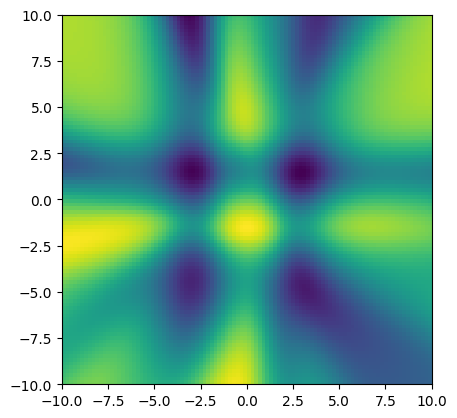

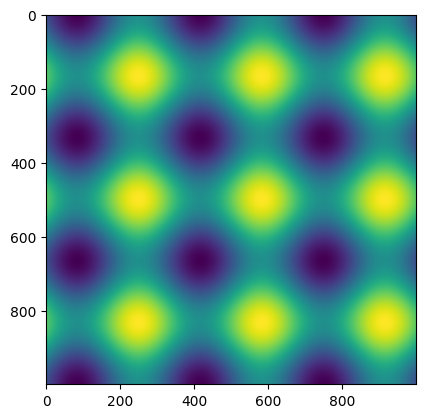

In [8]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 20),
    torch.nn.Sigmoid(),
    torch.nn.Linear(20,1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()


# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [33]:
# Your code here
import new_data

Define a new model and train it **poorly** in the cell below.

Iteration 0, Loss: 1285.8990478515625
Iteration 20, Loss: 1261.2728271484375
Iteration 40, Loss: 1233.3138427734375
Iteration 60, Loss: 1208.3497314453125
Iteration 80, Loss: 1189.14013671875


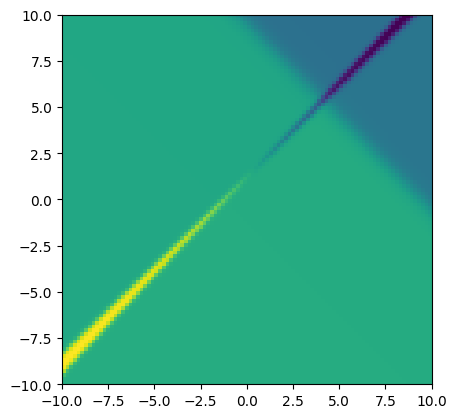

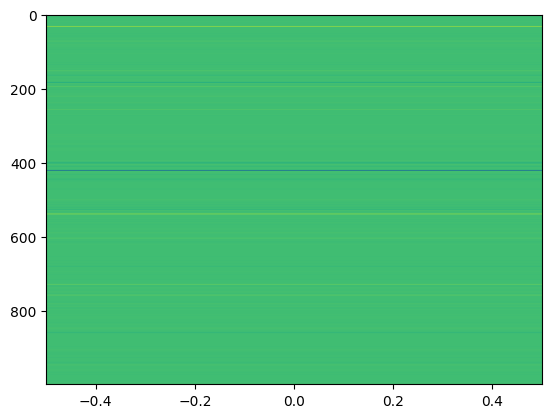

In [34]:
import importlib
import new_data
importlib.reload(new_data)

w_model = torch.nn.Sequential(
    torch.nn.Linear(2, 7),  
    torch.nn.Sigmoid(),
    torch.nn.Linear(7, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(w_model.parameters(), lr = 0.4)  

for t in range(100):
    y_pred = w_model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 20 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = w_model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

plt.imshow(new_data.color_values.reshape(1000, 1), aspect='auto')
plt.show()

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

Iteration 0, Loss: 1285.3663330078125
Iteration 100, Loss: 1285.3663330078125
Iteration 200, Loss: 1285.3663330078125
Iteration 300, Loss: 1285.3663330078125
Iteration 400, Loss: 1285.3663330078125
Iteration 500, Loss: 1285.3663330078125
Iteration 600, Loss: 1285.3663330078125
Iteration 700, Loss: 1285.3663330078125
Iteration 800, Loss: 1285.3663330078125
Iteration 900, Loss: 1285.3663330078125


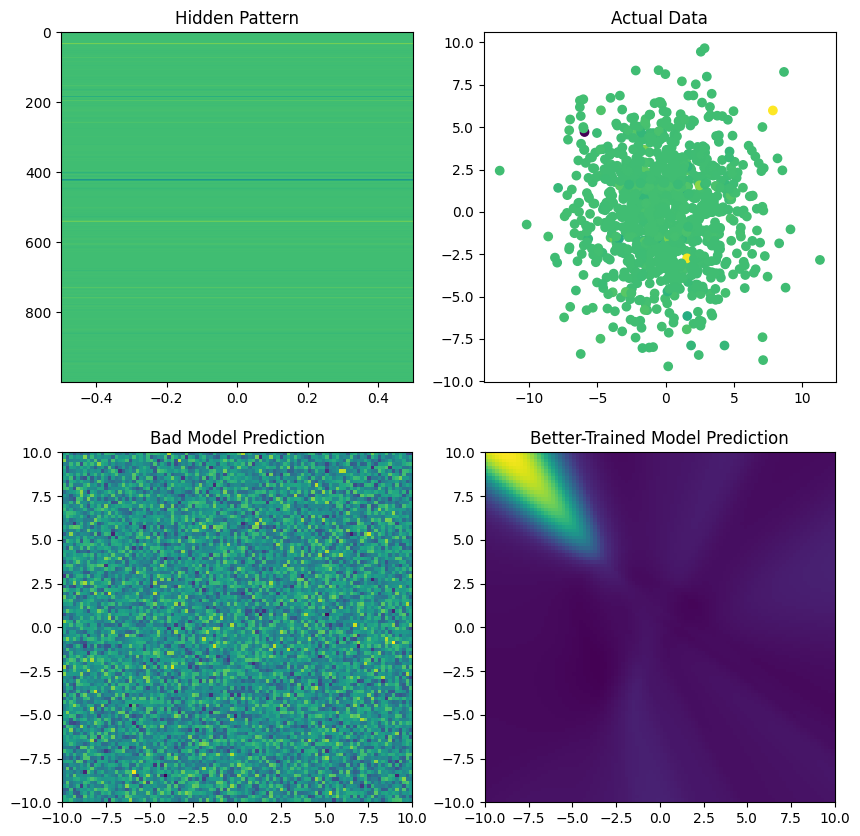

In [35]:
import torch
import matplotlib.pyplot as plt
import new_data

improved_model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(better_model.parameters(), lr=1e-2)

for t in range(1000):  
    y_pred = improved_model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')
        
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

poor_output = torch.randn_like(grid[..., :1])  
improved_output = improved_model(grid).detach()

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(new_data.color_values.reshape(1000, 1), aspect='auto')
axes[0, 0].set_title("Hidden Pattern")

axes[0, 1].scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)
axes[0, 1].set_title("Actual Data")

axes[1, 0].imshow(poor_output.numpy(), extent=(-10, 10, -10, 10))
axes[1, 0].set_title("Bad Model Prediction")

axes[1, 1].imshow(better_output.numpy(), extent=(-10, 10, -10, 10))
axes[1, 1].set_title("Better-Trained Model Prediction")

plt.show()

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [69]:
# I got my data from kaggle 
# my model is very simple so it doesnt match well. 

C:\Users\terra\AppData\Local\Temp\ipykernel_24036\3380646734.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['AQI Value'].fillna(data['AQI Value'].mean(), inplace=True)


Epoch [100/1000], Loss: 6709.9961
Epoch [200/1000], Loss: 6704.3530
Epoch [300/1000], Loss: 6698.6743
Epoch [400/1000], Loss: 6692.9390
Epoch [500/1000], Loss: 6687.1328
Epoch [600/1000], Loss: 6681.2432
Epoch [700/1000], Loss: 6675.2588
Epoch [800/1000], Loss: 6669.1724
Epoch [900/1000], Loss: 6662.9790
Epoch [1000/1000], Loss: 6656.6699
Mean Squared Error on Test Set: 6172.3496


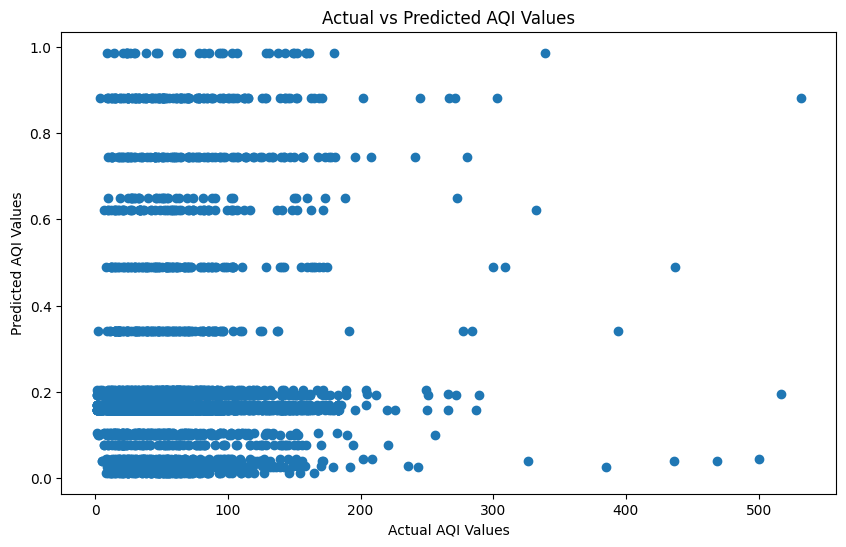

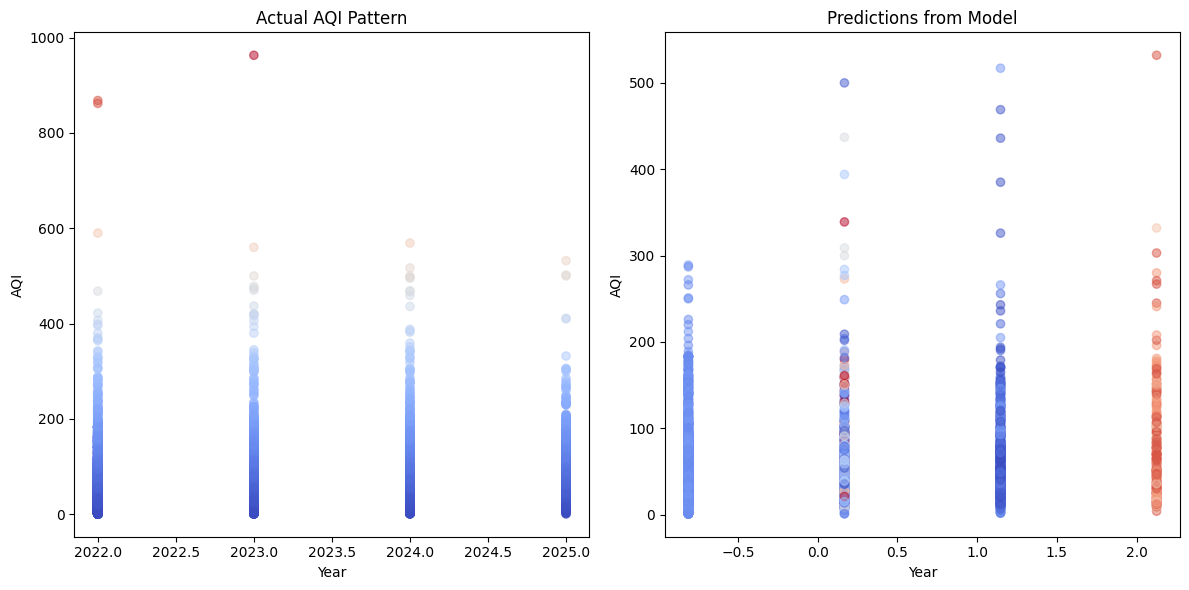

In [74]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('data_date.csv')

# Preprocess the data

# Convert 'date' to datetime format
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Extract year and month from the 'date' column
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

# Handle missing values in AQI value
data['AQI Value'].fillna(data['AQI Value'].mean(), inplace=True)

# Features (X) - Year and Month
X = data[['Year', 'Month']]

# Target (y) - AQI value
y = data['AQI Value']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Define the neural network model
class AQIPredictor(nn.Module):
    def __init__(self):
        super(AQIPredictor, self).__init__()
        self.fc1 = nn.Linear(X_train_tensor.shape[1], 50)  # Input size matches number of features
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(50, 20)
        self.fc3 = nn.Linear(20, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

# Define loss function and optimizer
model = AQIPredictor()
criterion = nn.MSELoss()  # Mean Squared Error for regression tasks
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    mse = criterion(predictions, y_test_tensor)
    print(f'Mean Squared Error on Test Set: {mse.item():.4f}')

# --- Visualization ---
# Convert tensors to NumPy for plotting
y_test_numpy = y_test_tensor.numpy()  # Convert to NumPy array for plotting
x_numpy = X_test_tensor.numpy()
predictions_numpy = predictions.detach().numpy()  # Detach the tensor and convert to NumPy array

# Compare actual vs predicted AQI values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_numpy, predictions_numpy)
plt.xlabel('Actual AQI Values')
plt.ylabel('Predicted AQI Values')
plt.title('Actual vs Predicted AQI Values')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Change to 1 row, 2 columns

# (Left) The actual pattern of temperature over time
axes[0].scatter(data['Year'], data['AQI Value'], c=data['AQI Value'], cmap='coolwarm', alpha=0.5)
axes[0].set_title("Actual AQI Pattern")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("AQI")

axes[1].scatter(X_test[:, 0], y_test_numpy, c=predictions.detach().numpy(), cmap='coolwarm', alpha=0.5)
axes[1].set_title("Predictions from Model")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("AQI")

plt.tight_layout()
plt.show()

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!

In [ ]:
# the error is really big but i dont knwo how to fix it, it already took me while
# to get it running at all. My guess is that it has to do with my chosen data and that the model is too simple.